In [ ]:
# Building a landscape stack:  This builds on what I developed in the 01_dev_create_disturbance_landscape_code


In [4]:
# Config dictionary: 

# Example stack config as a pure Python dict

landscape_stack_config = {
    "id_prefix": "DL",
    "id_strategy": "hash",   # or "uuid"
    "explicit_id": None,     # set to a string if you want to force an ID

    # --- Base disturbance landscape setup ---
    "tif_path": "downloaded_images/snic_10_2019_-12.004_132.979.tif",  # <-- change to your SNIC patch raster

    "disturbance_config": {
        "random": {
            "seed": None,    # or an int for reproducibility
        },
        "raster": {
            "band": 1,
        },
        "types": {
            "type1": {
                "name": "Conifer",
                "proportion_of_patches": 0.6,
                "initial_cover": {
                    "target_mean": 0.90,   # in (0,1)
                    "kappa": 20.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.02,
                        "background_alpha": 0.3,
                        "background_beta": 8.0,
                        "catastrophic_alpha": 8.0,
                        "catastrophic_beta": 0.7,
                    }
                },
            },
            "type2": {
                "name": "Broadleaf",
                "proportion_of_patches": 0.4,
                "initial_cover": {
                    "target_mean": 0.85,
                    "kappa": 18.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.05,
                        "background_alpha": 0.4,
                        "background_beta": 7.0,
                        "catastrophic_alpha": 7.0,
                        "catastrophic_beta": 0.8,
                    }
                },
            },
        },
        "thresholds": {
            "final_cover_percent": 15.0,
        },
        "simulation": {
            "max_retries": 10,
        },
        # Optional plotting defaults (you can ignore or tweak later)
        "plotting": {
            "type_cmap": "tab10",
            "initial_cover_cmap": "Greens",
            "proportional_loss_cmap": "Oranges",
            "loss_abs_cmap": "Reds",
            "final_cover_cmap": "Blues",
            "disturbed_cmap": "Greys_r",
        },
    },

    # --- Sensor configurations (arbitrary number of sensors) ---
    "sensors": [
        {
            "name": "Landsat_OLI",
            "config": {
                "signal_transform": {
                    "max_signal": 1000.0,
                    "curve_k": 3.0,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.02,
                },
                "types": {
                    # override type-specific behavior if desired
                    "type1": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.03,
                        }
                    },
                    "type2": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.01,
                        }
                    },
                },
                "lowpass_filter": {
                    "kernel_size": 3,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 10.0,
                    "amplitude_proportion_of_range": 0.10,
                },
            },
        },

        {
            "name": "Sentinel2_MSI",
            "config": {
                "signal_transform": {
                    "max_signal": 1500.0,
                    "curve_k": 2.5,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.015,
                },
                "lowpass_filter": {
                    "kernel_size": 5,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 15.0,
                    "amplitude_proportion_of_range": 0.12,
                },
            },
        },
    ],

    # --- Interpreter configuration (single interpreter) ---
    "interpreter": {
        "name": "DefaultInterpreter",
        "config": {
            "detection_curve": {
                "pivot_loss": 15.0,
                "slope": 0.3,
            },
            "definition_curve": {
                "slope": 0.4,
                "threshold_override": None,  # use DisturbanceLandscape threshold by default
            },
            "gaussian_patch_noise": {
                "std_dev_percent": 8.0,
            },
            "beta_patch_uncertainty": {
                "alpha": 2.0,
                "beta": 5.0,
            },
            "lowpass_filter": {
                "kernel_size": 3,
            },
            "spatial_uncertainty": {
                "spatial_autocorr_distance": 8.0,
                "max_scaler": 0.3,
            },
        },
    },
}

In [5]:
# load in one of the landscapes

from landscape_stack import LandscapeStack, LANDSCAPE_REGISTRY

stack = LandscapeStack.from_config(landscape_stack_config)

print("Stack ID:", stack.stack_id)
print("Sensors:", stack.list_sensors())
print("Registry keys:", LANDSCAPE_REGISTRY.keys())

Stack ID: DL_cb428280
Sensors: ['Landsat_OLI', 'Sentinel2_MSI']
Registry keys: dict_keys(['DL_cb428280'])


In [6]:
def plot_stack_summary(stack):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].imshow(stack.base_landscape.final_cover, cmap="Blues", vmin=0, vmax=100)
    axes[0].set_title("Final cover (%)")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], shrink=0.8)

    # Avg sensor field (optional synthesis)
    mean_sensor = sum(s.sensor_field for s in stack.sensor_fields.values()) / len(stack.sensor_fields)

    im1 = axes[1].imshow(mean_sensor, cmap="viridis")
    axes[1].set_title("Mean sensor response")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(stack.interpreter_field.interpreter_field, cmap="viridis", vmin=0, vmax=100)
    axes[2].set_title("Interpreter probability (%)")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2], shrink=0.8)

    plt.suptitle(f"Landscape stack: {stack.stack_id}")
    plt.tight_layout()
    plt.show()

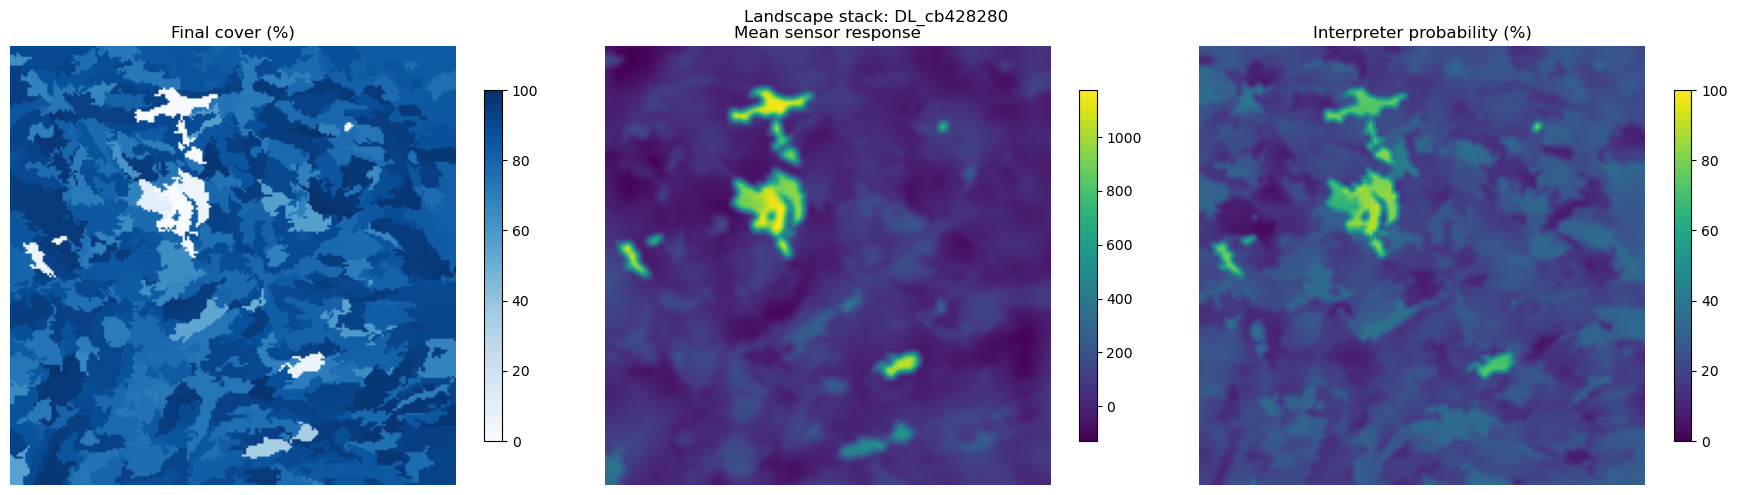

In [7]:
plot_stack_summary(stack)
